# A cleaner Root X?


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet


steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


In [2]:
def ccd_root_x_pulse(t, detuning):
    natural_freq = 10 # this is 10Ghz
    driving_freq = 10
    rabi_freq = 0.005 # this is 5Mhz

    # note that we are setting phase_freq to rabi_freq/16
    # we are also setting theta_m to pi2
    # as well as phi_0 
    epsilon_m = rabi_freq/4
    phase_freq = rabi_freq
    if t>=0 and t < 1/rabi_freq:
        phi_0 = np.pi/2
        theta_m = -np.pi/2
    else:
        phi_0 = 0
        theta_m = 0

    return {'natural_freq': natural_freq-detuning,
            'driving_freq': driving_freq,
            'rabi_freq': rabi_freq,
            'epsilon_m': epsilon_m,
            'phase_freq': phase_freq,
            'phi_0': phi_0,
            'theta_m': theta_m}

In [19]:
def generate_ccd_pulse_function(phi, theta):
    def ccd_pulse(t, detuning):
        natural_freq = 10  # this is 10GHz
        driving_freq = 10
        rabi_freq = 0.005  # this is 5MHz

        # note that we are setting phase_freq to rabi_freq/16
        # we are also setting theta_m to pi2
        # as well as phi_0 
        epsilon_m = rabi_freq / 4
        phase_freq = rabi_freq
        if 0 <= t < 1 / rabi_freq:
            phi_0 = phi
            theta_m = theta
        else:
            phi_0 = 0
            theta_m = 0

        return {
            'natural_freq': natural_freq - detuning,
            'driving_freq': driving_freq,
            'rabi_freq': rabi_freq,
            'epsilon_m': epsilon_m,
            'phase_freq': phase_freq,
            'phi_0': phi_0,
            'theta_m': theta_m
        }
    return ccd_pulse

In [10]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



tol = 10**-5
evaluation_points = 2000
evaluation_time = 4/(rabi_freq)

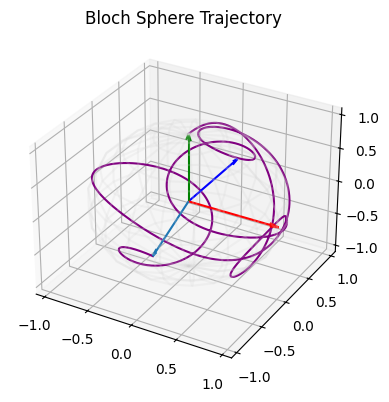

In [16]:
times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, ccd_root_x_pulse, detuning=0)
initial_state = np.array([1+0j,0+0j])

transformed_Us  = qt.virtual_z(Us_driving_frame, np.pi/2)

states = []
for U in transformed_Us:
    states.append(U @ initial_state)
states = np.array(states)



qt.visualise_solution(times, states)

In [17]:
qt.calculate_fidelities(root_x, transformed_Us, 2)

array([0.5       , 0.49791117, 0.49583567, ..., 0.98646803, 0.98516263,
       0.98379414])

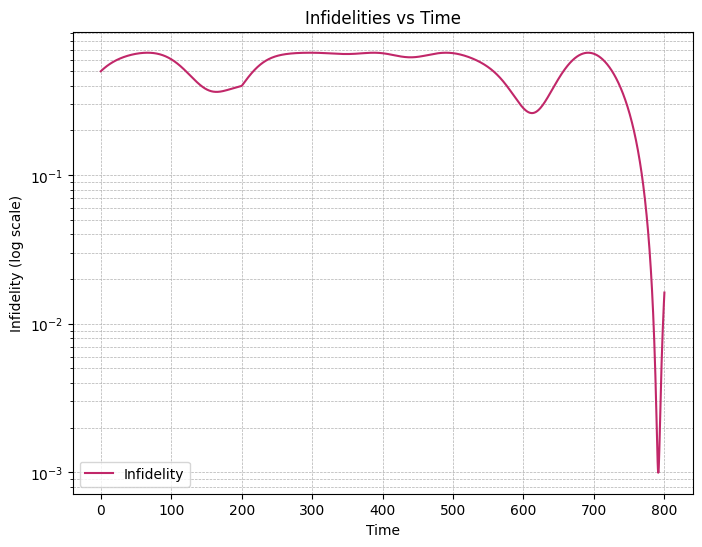

In [18]:
# Calculate fidelities
fidelities = qt.calculate_fidelities(root_x, transformed_Us, 2)

# Calculate infidelities
infidelities = 1 - fidelities

# Plot infidelities against time on a log scale
plt.figure(figsize=(8, 6))
plt.plot(times, infidelities, color=deep_magenta, label='Infidelity')
plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('Infidelity (log scale)')
plt.title('Infidelities vs Time')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

In [42]:
import numpy as np
from scipy.optimize import minimize



# Create a quantum system with a single qubit
natural_freq = 10 # this is 10Ghz
driving_freq = 10
rabi_freq = 0.005 # this is 5Mhz

# note that we are setting phase_freq to rabi_freq/16
# we are also setting theta_m to pi2
# as well as phi_0 


evaluation_points = 1000
evaluation_time = 4/rabi_freq
tol = 10**-12



# Objective function: 1 - fidelity (since we are minimising)
def objective(params):
    phi, theta, rotation_angle = params
    phi = phi * np.pi
    theta = theta * np.pi
    rotation_angle = rotation_angle*np.pi
    # make the pulse function   
    pulse = generate_ccd_pulse_function(phi, theta)

    try:
        _, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, pulse, detuning=0)

        transformed_Us  = qt.virtual_z(Us_driving_frame, rotation_angle)
       
        fid = qt.calculate_fidelities(root_x, transformed_Us, 2)
        return 1 - fid[-1]  # We want to maximise fidelity, so minimise 1 - fidelity

    except Exception as e:
        print(f"Error during evaluation: {e}")
        return 1  # Return high loss if something breaks

# Initial guess and bounds
initial_guess = [1/2, -1/2, 1/2]
bounds = [(-2, 2), (-2, 2), (0, 2)]

# Run optimisation
result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')

# Extract and print optimal values
optimal_phi, optimal_theta, optimal_rotation_angle = result.x

optimal_fidelity = 1 - result.fun

print(f"✅ Optimal φ: {optimal_phi} x π ")
print(f"✅ Optimal θ: {optimal_theta} x π ")
print(f"✅ Optimal rotation angle: {optimal_rotation_angle}")
print(f"🎯 Max Fidelity: {optimal_fidelity}")

# make the optimal pulse
optimal_pulse = generate_ccd_pulse_function(optimal_phi*np.pi, optimal_theta*np.pi)


✅ Optimal φ: 0.5272773150184948 x π 
✅ Optimal θ: -0.4043605534192049 x π 
✅ Optimal rotation angle: 0.32921934778900297
🎯 Max Fidelity: 0.9999994449384317


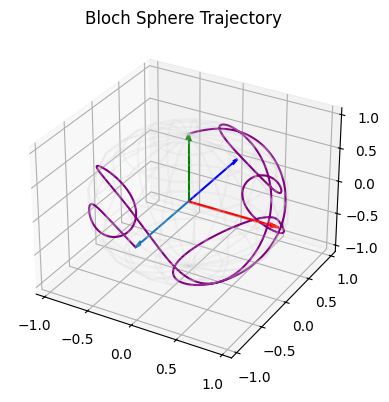

In [43]:
times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, optimal_pulse, detuning=0)
initial_state = np.array([1+0j,0+0j])

transformed_Us  = qt.virtual_z(Us_driving_frame, optimal_rotation_angle*np.pi)

states = []
for U in transformed_Us:
    states.append(U @ initial_state)
states = np.array(states)



qt.visualise_solution(times, states)

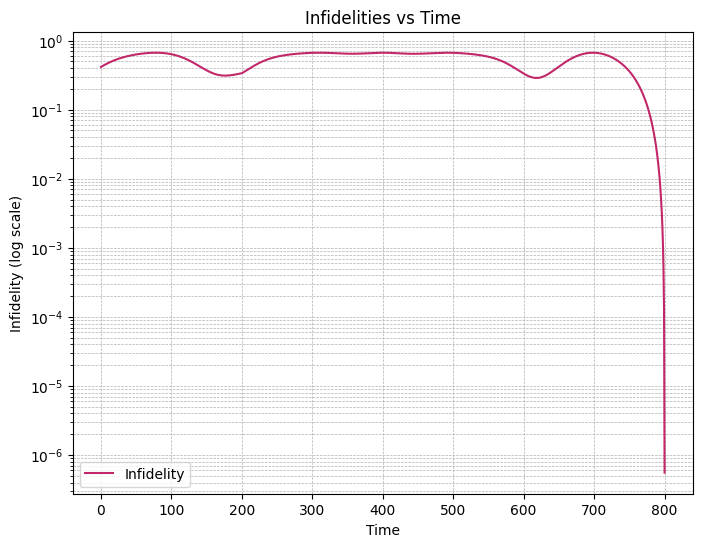

In [44]:
# Calculate fidelities
fidelities = qt.calculate_fidelities(root_x, transformed_Us, 2)

# Calculate infidelities
infidelities = 1 - fidelities

# Plot infidelities against time on a log scale
plt.figure(figsize=(8, 6))
plt.plot(times, infidelities, color=deep_magenta, label='Infidelity')
plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('Infidelity (log scale)')
plt.title('Infidelities vs Time')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

# Ok cool - now we have a more conventional root x in the ccd scheme - investigate the crosstalk

In [46]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)

fids_1 = []
fids_2 = []
fids_combined = []

# First calculate fidelity for qubit 1 (root-x gate)
times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, optimal_pulse, detuning=0)
transformed_Us  = qt.virtual_z(Us_driving_frame, optimal_rotation_angle*np.pi)
fid_1 = qt.calculate_fidelities(root_x, transformed_Us, 2)

# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:
    fids_1.append(fid_1)
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, optimal_pulse, detuning=detuning)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    
    # Calculate combined fidelity
    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_ccd = [fid[-1] for fid in fids_combined]

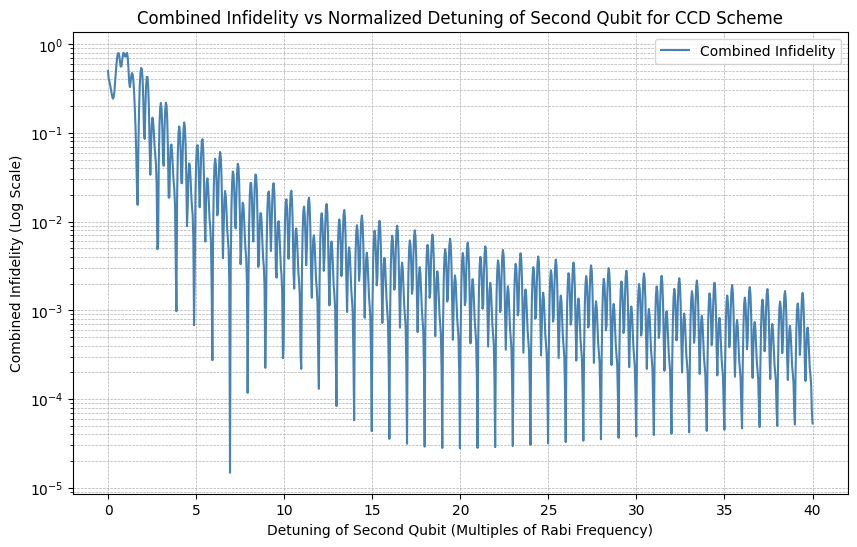

In [47]:
# find combdined infidelity
infidelities_combined_ccd = 1-np.array(final_fids_combined_ccd)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="Combined Infidelity", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


# Rabi

In [48]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 1/(4*rabi_freq)

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)



fids_1 = []
fids_2 = []
fids_combined = []

times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+0, driving_freq=driving_freq, rabi_freq=rabi_freq)
fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)


for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)

    fids_1.append(fid_1)

    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)

    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)

# Extract the final time step fidelity for each detuning
final_fids_combined_rabi = [fid[-1] for fid in fids_combined]


# Plot them together

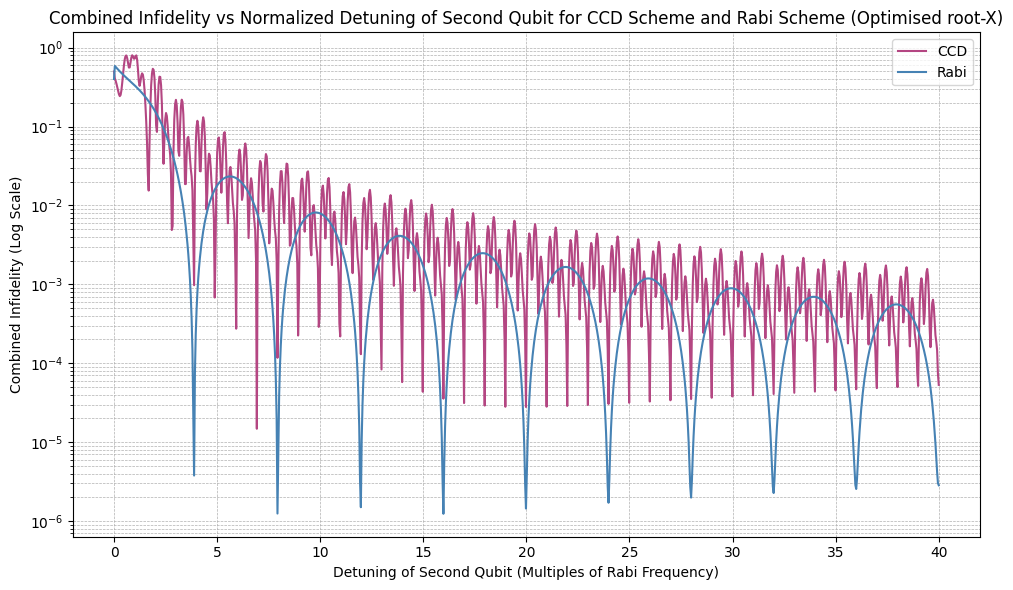

In [49]:
# find combdined infidelity
infidelities_combined_ccd = 1-np.array(final_fids_combined_ccd)
infidelities_combined_rabi = 1-np.array(final_fids_combined_rabi)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="CCD", color=plum)
plt.semilogy(detunings_normalized, infidelities_combined_rabi, label="Rabi", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Optimised root-X)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/root_x_cross_talk_scaling.png', dpi=600)
plt.show()



# hmmmm

# Calculate for just the second qubit

In [55]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0.48507178492998143*np.pi, rabi_freq/16, rabi_freq, -0.49999999968816566*np.pi


# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 4/rabi_freq

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)


fids_2 = []




# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries_pulse(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa, optimal_pulse, detuning=detuning)
    

    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)
    transformed_Us  = qt.virtual_z(transformed_Us, optimal_rotation_angle*np.pi)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    

# Extract the final time step fidelity for each detuning
final_fids_2_ccd = [fid[-1] for fid in fids_2]

In [51]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005



# Integration parameters
tol = 10**-12
evaluation_points = 2000
evaluation_time = 1/(4*rabi_freq)

# iteration parameters
detunings = np.linspace(0, 40*rabi_freq, 1000)




fids_2 = []


for detuning in detunings:
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.rabi_rwa, natural_freq=natural_freq+detuning, driving_freq=driving_freq, rabi_freq=rabi_freq)



    effective_rabi_freq = np.sign(detuning)*np.sqrt(rabi_freq**2 + detuning**2)
    Us_effective_rabi = qt.phase_boost_unitaries(Us_driving_frame, -effective_rabi_freq, times)
    fid_2 = qt.calculate_fidelities(np.eye(2), Us_effective_rabi, 2)
    fids_2.append(fid_2)



# Extract the final time step fidelity for each detuning
final_fids_2_rabi = [fid[-1] for fid in fids_2]


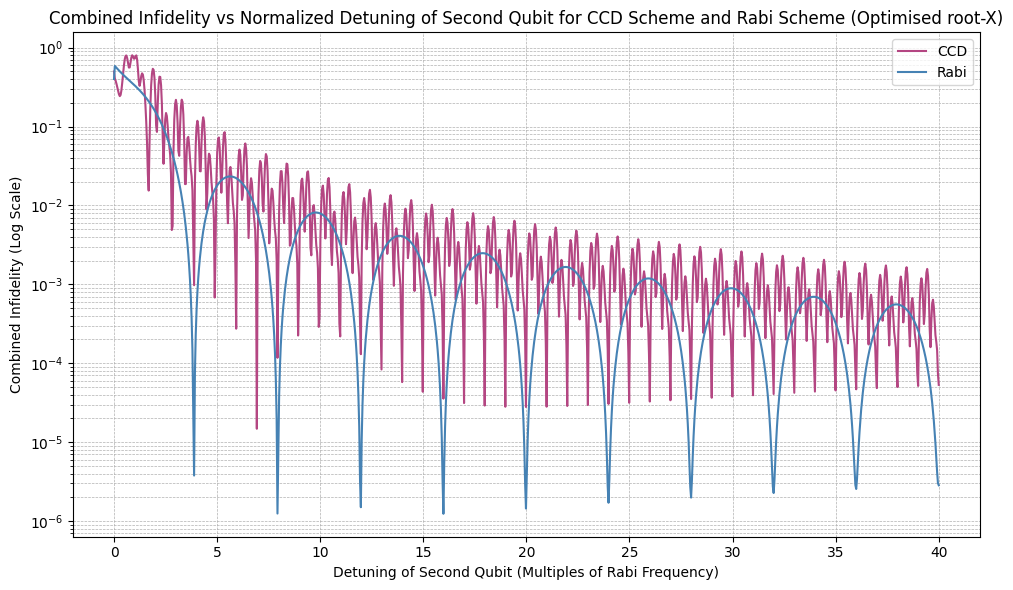

In [56]:
# find combdined infidelity
infidelities_2_ccd = 1-np.array(final_fids_2_ccd)
infidelities_2_rabi = 1-np.array(final_fids_2_rabi)

# Normalize detunings by Rabi frequency
detunings_normalized = detunings / rabi_freq

# Plot combined infidelity vs normalized detuning on a logarithmic scale
plt.figure(figsize=(10, 6))
plt.semilogy(detunings_normalized, infidelities_combined_ccd, label="CCD", color=plum)
plt.semilogy(detunings_normalized, infidelities_combined_rabi, label="Rabi", color=steel_blue)
plt.xlabel("Detuning of Second Qubit (Multiples of Rabi Frequency)")
plt.ylabel("Combined Infidelity (Log Scale)")
plt.title("Combined Infidelity vs Normalized Detuning of Second Qubit for CCD Scheme and Rabi Scheme (Optimised root-X)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/root_x_cross_talk_scaling.png', dpi=600)
plt.show()

